In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


# Check if GPU is available for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class MinecraftDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Custom Dataset to load 16x16 PNG images directly from a folder.
        """
        self.root_dir = root_dir
        self.transform = transform
        # List all png files in the directory
        self.file_names = [f for f in os.listdir(root_dir) if f.endswith('.png')]

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.file_names[idx])
        # Open image and ensure it is RGB (removes alpha channel if present)
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, self.file_names[idx] # Returning filename for arithmetic reference

def load_minecraft_dataset(folder_path, batch_size=32):
    # Standard transformations for 16x16 images
    transform = transforms.Compose([
        transforms.Resize((16, 16)),
        transforms.ToTensor(), # Scales pixels to [0.0, 1.0] and HWC -> CHW
    ])

    dataset = MinecraftDataset(root_dir=folder_path, transform=transform)
    
    dataloader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=True
    )
    
    return dataloader, dataset

# Initialize the loader
DATA_FOLDER = "minecraft-items"
train_loader, full_dataset = load_minecraft_dataset(DATA_FOLDER, batch_size=32)

# Quick check to verify dimensions
sample_batch, sample_filenames = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}") # Expected: [32, 3, 16, 16]

Batch shape: torch.Size([32, 3, 16, 16])


In [3]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        
        # Input features calculation: 16 (height) * 16 (width) * 3 (channels) = 768
        input_dim = 16 * 16 * 3
        
        # Encoder: compress input to latent vector
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 256), # Reduced hidden layers size for 16x16 images
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        
        # Decoder: reconstruct input from latent vector
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid() # Scale output to [0, 1] matching our normalized tensors
        )

    def forward(self, x):
        # Encode
        z = self.encoder(x)
        
        # Decode
        reconstruction = self.decoder(z)
        
        # Reshape back to image dimensions (Batch, Channels, Height, Width)
        # Using 16x16 as requested
        return reconstruction.view(-1, 3, 16, 16)

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        
        # Input features calculation: 16*16*3 = 768
        input_dim = 16 * 16 * 3
        hidden_dim = 256
        
        # Shared encoder layers
        self.encoder_backbone = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        
        # Separate heads for mean and log variance
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid() # Scale output to [0, 1]
        )

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick to sample z while allowing backpropagation.
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Encode to shared representation
        h = self.encoder_backbone(x)
        
        # Get latent distributions parameters
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        # Sample z using the reparameterization trick
        z = self.reparameterize(mu, logvar)
        
        # Decode and reshape back to 16x16 image
        recon_x = self.decoder(z).view(-1, 3, 16, 16)
        
        return recon_x, mu, logvar

In [5]:
def vae_loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE or Binary Cross Entropy)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL Divergence: forces the latent distribution towards N(0,1)
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + (0.1 * kld_loss)

# Training loop logic goes here

In [6]:
def perform_latent_arithmetic(model, img_a, img_b, img_c):
    model.eval()
    with torch.no_grad():
        # Encode images to get their latent vectors (mu)
        _, mu_a, _ = model(img_a)
        _, mu_b, _ = model(img_b)
        _, mu_c, _ = model(img_c)
        
        # Perform vector arithmetic
        # Example: Modified = A - B + C
        target_vector = mu_a - mu_b + mu_c
        
        # Decode the resulting vector back to an image
        generated_img = model.decoder(target_vector).view(3, 32, 32)
        return generated_img

In [7]:
def train_model(model, dataloader, epochs=50, learning_rate=1e-3, is_vae=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    model.train()
    
    loss_history = []
    
    for epoch in range(epochs):
        train_loss = 0
        for batch_idx, (data, _) in enumerate(dataloader):
            data = data.to(device)
            optimizer.zero_grad()
            
            if is_vae:
                recon_batch, mu, logvar = model(data)
                loss = vae_loss_function(recon_batch, data, mu, logvar)
            else:
                recon_batch = model(data)
                loss = F.mse_loss(recon_batch, data, reduction='sum')
            
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
        
        avg_loss = train_loss / len(dataloader.dataset)
        loss_history.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
            
    return loss_history

In [ ]:
def get_latent_vector(model, image_path, transform):
    """ Helper to get the latent vector (mu) for a specific image file. """
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        if isinstance(model, VAE):
            h = model.encoder_backbone(image)
            mu = model.fc_mu(h)
            return mu
        else:
            return model.encoder(image)

def perform_arithmetic(model, base_vec, minus_vec, plus_vec):
    """ Performs: Result = Base - Minus + Plus """
    model.eval()
    with torch.no_grad():
        result_vec = base_vec - minus_vec + plus_vec
        
        # Decode the resulting vector
        generated_img = model.decoder(result_vec).view(3, 16, 16).cpu()
        return generated_img

In [9]:
def plot_reconstructions(model, dataloader, n=5):
    model.eval()
    images, _ = next(iter(dataloader))
    images = images.to(device)
    
    with torch.no_grad():
        if isinstance(model, VAE):
            recon, _, _ = model(images)
        else:
            recon = model(images)
    
    images = images.cpu()
    recon = recon.cpu()
    
    fig, axes = plt.subplots(2, n, figsize=(n*2, 4))
    for i in range(n):
        # Original
        axes[0, i].imshow(images[i].permute(1, 2, 0))
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("Original")
        
        # Reconstruction
        axes[1, i].imshow(recon[i].permute(1, 2, 0))
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title("Reconstructed")
    plt.show()

In [10]:
def get_average_latent_vector(model, dataset, keyword):
    """
    Calculates the average latent vector for all items containing a specific keyword in the filename.
    """
    model.eval()
    vectors = []
    
    with torch.no_grad():
        for i in range(len(dataset)):
            img, filename = dataset[i]
            if keyword in filename.lower():
                img = img.unsqueeze(0).to(device)
                if isinstance(model, VAE):
                    # Use the mean vector (mu) as the representative latent point
                    h = model.encoder_backbone(img)
                    mu = model.fc_mu(h)
                    vectors.append(mu)
                else:
                    vectors.append(model.encoder(img))
    
    if len(vectors) == 0:
        print(f"Warning: No items found with keyword '{keyword}'")
        return torch.zeros((1, LATENT_DIM)).to(device)
        
    return torch.mean(torch.stack(vectors), dim=0)

In [11]:
# Define the dimensionality of the latent space
LATENT_DIM = 32

# Initialize models and move them to the target device (GPU/CPU)
ae_model = Autoencoder(LATENT_DIM).to(device)
vae_model = VAE(LATENT_DIM).to(device)

# Define transformations for individual test images
test_transform = transforms.Compose([
    transforms.Resize((16, 16)),
    transforms.ToTensor(),
])

In [12]:
print("Training AE...")
ae_loss = train_model(ae_model, train_loader, epochs=50, is_vae=False)

Training AE...
Epoch 10/50, Loss: 26.3707
Epoch 20/50, Loss: 17.5908
Epoch 30/50, Loss: 13.8849
Epoch 40/50, Loss: 11.4798
Epoch 50/50, Loss: 9.9699


In [13]:
print("Training VAE...")
vae_loss = train_model(vae_model, train_loader, epochs=50, is_vae=True)

Training VAE...
Epoch 10/50, Loss: 26.1321
Epoch 20/50, Loss: 18.5690
Epoch 30/50, Loss: 14.8616
Epoch 40/50, Loss: 13.3199
Epoch 50/50, Loss: 11.9113


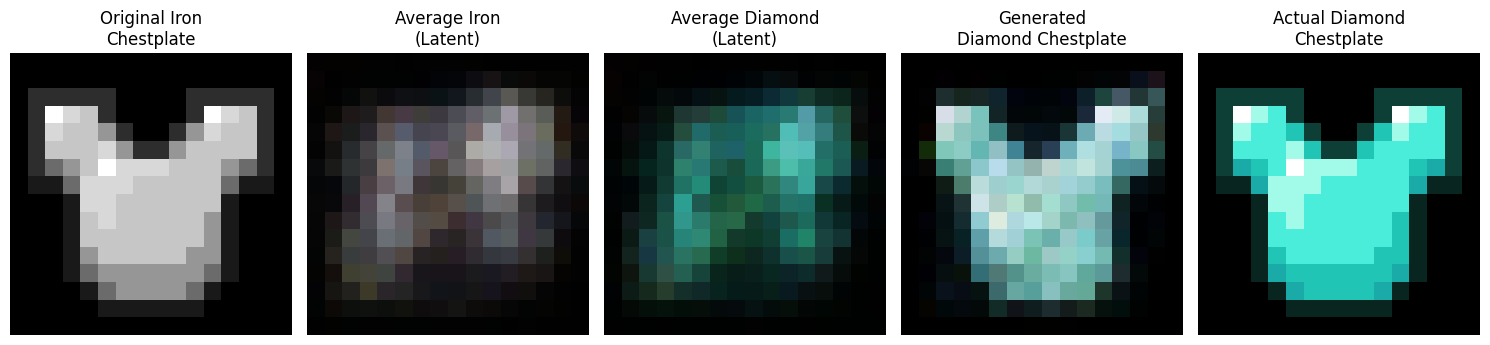

In [14]:
# Calculate the average (centroid) vectors for materials
avg_iron_vec = get_average_latent_vector(vae_model, full_dataset, "iron")
avg_diamond_vec = get_average_latent_vector(vae_model, full_dataset, "diamond")

# Load specific chestplates for the comparison
# Ensure these files exist in your "minecraft-items" folder
iron_chest_vec = get_latent_vector(vae_model, "minecraft-items/iron_chestplate.png", test_transform)
actual_diamond_chest_img = Image.open("minecraft-items/diamond_chestplate.png").convert("RGB")
actual_diamond_chest_tensor = test_transform(actual_diamond_chest_img)

# Perform Arithmetic: Result = Iron Chestplate - Average Iron + Average Diamond
with torch.no_grad():
    expected_diamond_vec = iron_chest_vec - avg_iron_vec + avg_diamond_vec
    generated_img = vae_model.decoder(expected_diamond_vec).view(3, 16, 16).cpu()

# Decode the average vectors to visualize what the 'material' looks like
with torch.no_grad():
    avg_iron_img = vae_model.decoder(avg_iron_vec).view(3, 16, 16).cpu()
    avg_diamond_img = vae_model.decoder(avg_diamond_vec).view(3, 16, 16).cpu()

# Final visualization of the transformation chain
titles = [
    "Original Iron\nChestplate", 
    "Average Iron\n(Latent)", 
    "Average Diamond\n(Latent)", 
    "Generated\nDiamond Chestplate", 
    "Actual Diamond\nChestplate"
]

imgs = [
    Image.open("minecraft-items/iron_chestplate.png").convert("RGB"), 
    avg_iron_img.permute(1, 2, 0), 
    avg_diamond_img.permute(1, 2, 0), 
    generated_img.permute(1, 2, 0), 
    actual_diamond_chest_tensor.permute(1, 2, 0)
]

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(imgs[i])
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

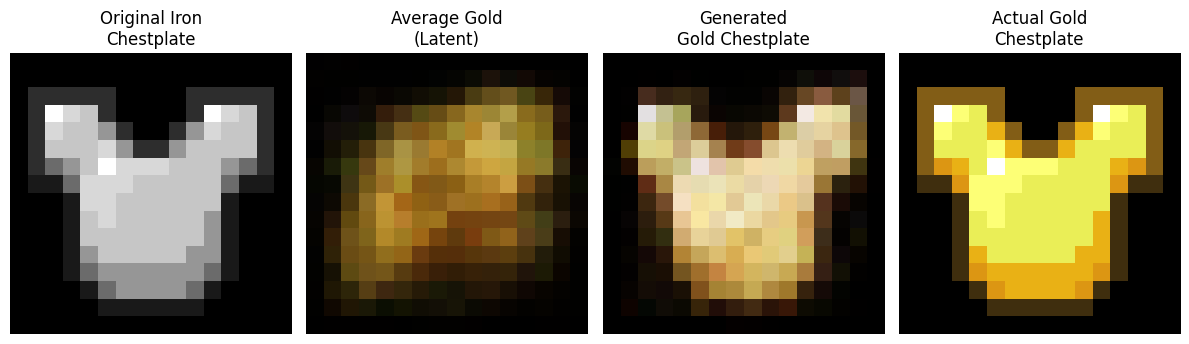

In [15]:
# Calculate the average latent vector for gold items
avg_gold_vec = get_average_latent_vector(vae_model, full_dataset, "gold")

# Perform Arithmetic: Result = Iron Chestplate - Average Iron + Average Gold
with torch.no_grad():
    # Uses iron_chest_vec and avg_iron_vec from the previous experiment
    expected_gold_vec = iron_chest_vec - avg_iron_vec + avg_gold_vec
    generated_gold_img = vae_model.decoder(expected_gold_vec).view(3, 16, 16).cpu()

# Decode the average gold vector to visualize the learned material properties
with torch.no_grad():
    avg_gold_visual = vae_model.decoder(avg_gold_vec).view(3, 16, 16).cpu()

# Attempt to load the actual gold chestplate for ground truth comparison
try:
    actual_gold_img = Image.open("minecraft-items/gold_chestplate.png").convert("RGB")
    actual_gold_tensor = test_transform(actual_gold_img).permute(1, 2, 0)
    has_actual = True
except FileNotFoundError:
    has_actual = False

# Setup visualization
titles_gold = [
    "Original Iron\nChestplate", 
    "Average Gold\n(Latent)", 
    "Generated\nGold Chestplate"
]
imgs_gold = [
    Image.open("minecraft-items/iron_chestplate.png").convert("RGB"), 
    avg_gold_visual.permute(1, 2, 0), 
    generated_gold_img.permute(1, 2, 0)
]

# Add actual gold chestplate to the comparison if the file exists
if has_actual:
    titles_gold.append("Actual Gold\nChestplate")
    imgs_gold.append(actual_gold_tensor)

plt.figure(figsize=(12, 5))
for i in range(len(imgs_gold)):
    plt.subplot(1, len(imgs_gold), i+1)
    plt.imshow(imgs_gold[i])
    plt.title(titles_gold[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

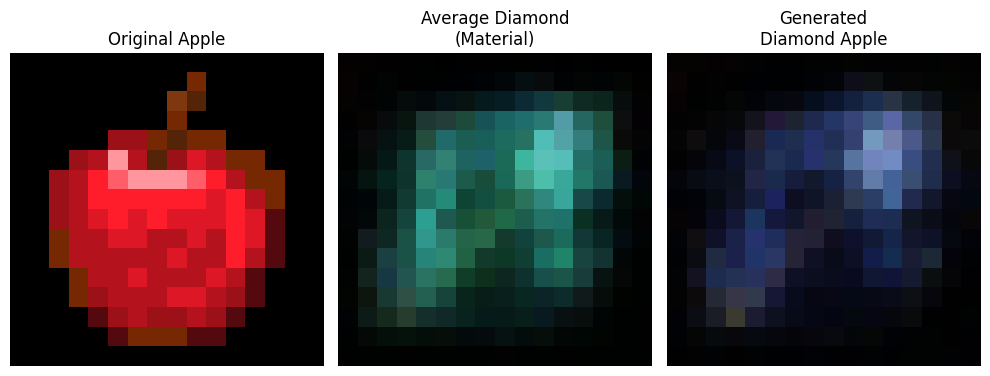

In [16]:
# Calculate the average latent vector for diamond items (if not already in memory)
avg_diamond_vec = get_average_latent_vector(vae_model, full_dataset, "diamond")

# Calculate the average latent vector for standard apples to find the 'apple' shape
# This helps the model isolate the 'apple-ness' from the 'red-ness'
avg_apple_vec = get_average_latent_vector(vae_model, full_dataset, "apple")

# Load the base image: the standard red apple
# Ensure 'apple.png' or 'red_apple.png' exists in your folder
apple_path = "minecraft-items/apple.png" 
base_apple_vec = get_latent_vector(vae_model, apple_path, test_transform)

# Perform Arithmetic: Result = Red Apple - Average Apple + Average Diamond
with torch.no_grad():
    # We subtract the average apple to 'neutralize' the red material 
    # and add diamond to apply the new texture
    expected_diamond_apple_vec = base_apple_vec - avg_apple_vec + avg_diamond_vec
    generated_diamond_apple = vae_model.decoder(expected_diamond_apple_vec).view(3, 16, 16).cpu()

# Visualization
titles_apple = [
    "Original Apple", 
    "Average Diamond\n(Material)", 
    "Generated\nDiamond Apple"
]

imgs_apple = [
    Image.open(apple_path).convert("RGB"), 
    vae_model.decoder(avg_diamond_vec).view(3, 16, 16).detach().cpu().permute(1, 2, 0), 
    generated_diamond_apple.permute(1, 2, 0)
]

plt.figure(figsize=(10, 5))
for i in range(len(imgs_apple)):
    plt.subplot(1, 3, i+1)
    plt.imshow(imgs_apple[i])
    plt.title(titles_apple[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

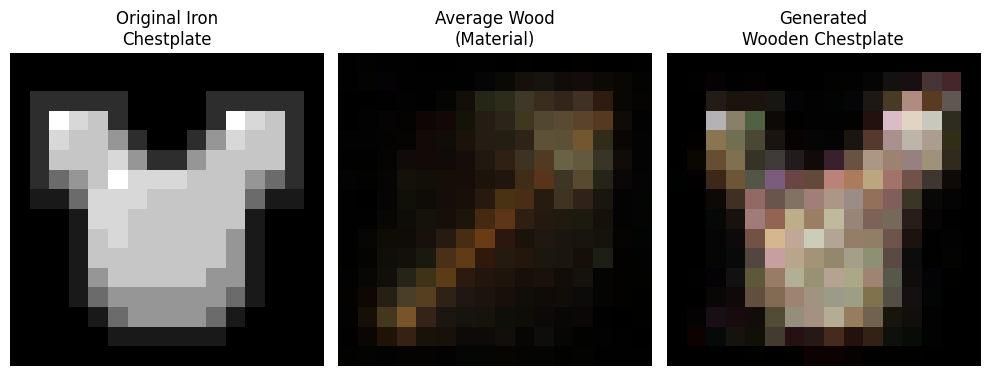

In [17]:
# Calculate the average latent vector for wood items
# This looks for items like 'oak_planks', 'stick', 'wooden_pickaxe', etc.
avg_wood_vec = get_average_latent_vector(vae_model, full_dataset, "wood")

# Perform Arithmetic: Result = Iron Chestplate - Average Iron + Average Wood
with torch.no_grad():
    # We use the iron_chest_vec and avg_iron_vec from the previous experiment
    expected_wood_vec = iron_chest_vec - avg_iron_vec + avg_wood_vec
    generated_wood_img = vae_model.decoder(expected_wood_vec).view(3, 16, 16).cpu()

# Decode the average wood vector for visualization
with torch.no_grad():
    avg_wood_visual = vae_model.decoder(avg_wood_vec).view(3, 16, 16).cpu()

# Visualization
titles_wood = [
    "Original Iron\nChestplate", 
    "Average Wood\n(Material)", 
    "Generated\nWooden Chestplate"
]

imgs_wood = [
    Image.open("minecraft-items/iron_chestplate.png").convert("RGB"), 
    avg_wood_visual.permute(1, 2, 0), 
    generated_wood_img.permute(1, 2, 0)
]

plt.figure(figsize=(10, 5))
for i in range(len(imgs_wood)):
    plt.subplot(1, 3, i+1)
    plt.imshow(imgs_wood[i])
    plt.title(titles_wood[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

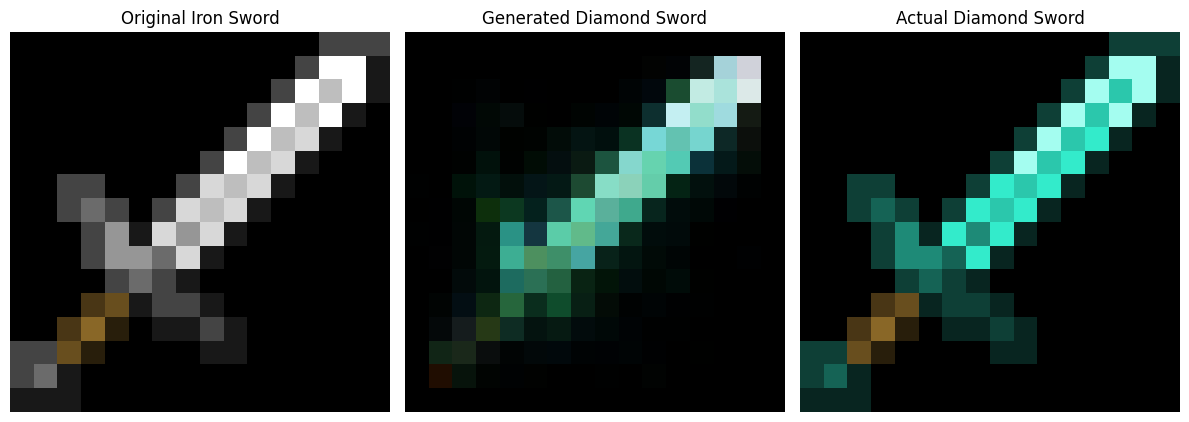

In [20]:
# Load the latent vector for the base item: Iron Sword
# Ensure 'iron_sword.png' exists in your "minecraft-items" folder
iron_sword_path = "minecraft-items/iron_sword.png"
iron_sword_vec = get_latent_vector(vae_model, iron_sword_path, test_transform)

# Perform Arithmetic: Result = Iron Sword - Average Iron + Average Diamond
with torch.no_grad():
    # Subtracting avg_iron_vec removes the 'iron' characteristics
    # Adding avg_diamond_vec injects the 'diamond' characteristics
    expected_diamond_sword_vec = iron_sword_vec - avg_iron_vec + avg_diamond_vec
    generated_diamond_sword = vae_model.decoder(expected_diamond_sword_vec).view(3, 16, 16).cpu()

# Attempt to load the actual diamond sword for comparison
try:
    actual_diamond_sword_img = Image.open("minecraft-items/diamond_sword.png").convert("RGB")
    actual_diamond_sword_tensor = test_transform(actual_diamond_sword_img).permute(1, 2, 0)
    has_actual_sword = True
except FileNotFoundError:
    has_actual_sword = False

# Visualization setup
titles_sword = ["Original Iron Sword", "Generated Diamond Sword"]
imgs_sword = [
    Image.open(iron_sword_path).convert("RGB"), 
    generated_diamond_sword.permute(1, 2, 0)
]

# Add actual diamond sword to the plot if the file exists
if has_actual_sword:
    titles_sword.append("Actual Diamond Sword")
    imgs_sword.append(actual_diamond_sword_tensor)

plt.figure(figsize=(12, 5))
for i in range(len(imgs_sword)):
    plt.subplot(1, len(imgs_sword), i+1)
    plt.imshow(imgs_sword[i])
    plt.title(titles_sword[i])
    plt.axis('off')
plt.tight_layout()
plt.show()